In [29]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from tqdm.auto import tqdm
import kagglehub

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [30]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [31]:
data_path = kagglehub.dataset_download("mirichoi0218/insurance", path='insurance.csv')

df = pd.read_csv(data_path)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [32]:
print(df.shape)

df.info()

(1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [33]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [34]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [35]:
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    print(df[col].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


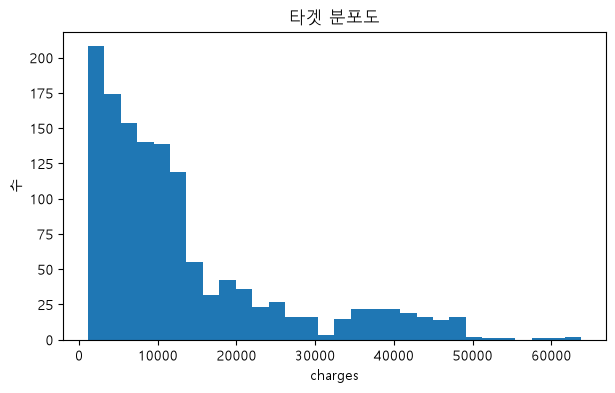

In [36]:
plt.figure(figsize=(7, 4))
plt.hist(df['charges'], bins=30)
plt.title('타겟 분포도')
plt.xlabel('charges')
plt.ylabel('수')
plt.show()

<Figure size 700x400 with 0 Axes>

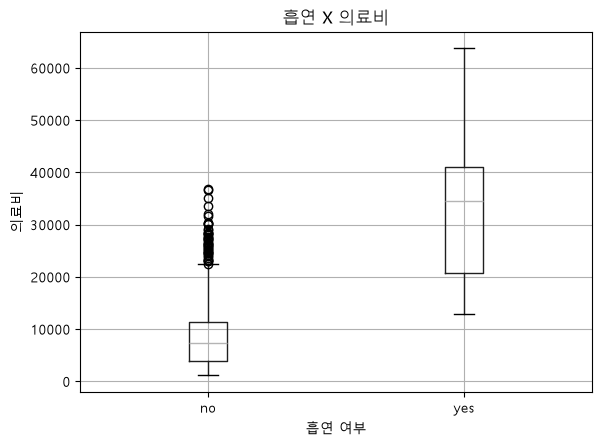

In [37]:
plt.figure(figsize=(7, 4))
df.boxplot(column='charges', by='smoker')
plt.title('흡연 X 의료비')
plt.suptitle('')
plt.xlabel('흡연 여부')
plt.ylabel('의료비')
plt.show()

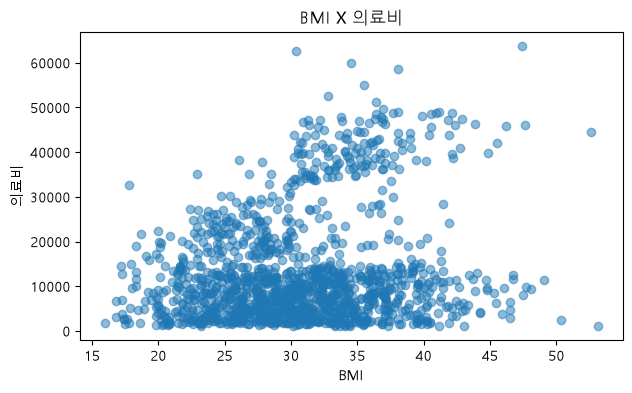

In [38]:
plt.figure(figsize=(7, 4))
plt.scatter(df['bmi'], df['charges'], alpha=0.5)
plt.title('BMI X 의료비')
plt.xlabel('BMI')
plt.ylabel('의료비')
plt.show()

In [39]:
X = df.drop(columns='charges')
y = df['charges']

print(X.shape, y.shape)

(1338, 6) (1338,)


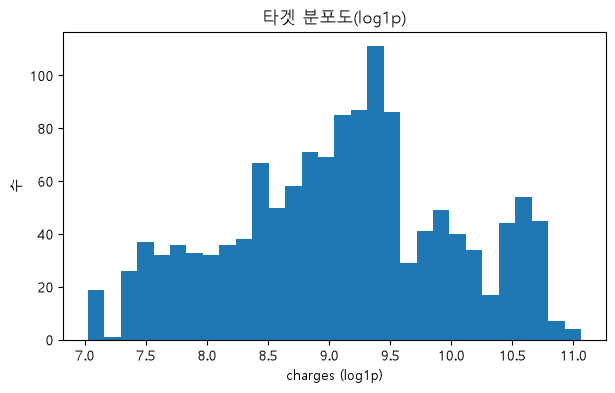

In [40]:
y_log = np.log1p(y)
plt.figure(figsize=(7, 4))
plt.hist(y_log, bins=30)
plt.title('타겟 분포도(log1p)')
plt.xlabel('charges (log1p)')
plt.ylabel('수')
plt.show()

In [41]:
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=SEED
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size=0.2,
    random_state=SEED
)

print(f'X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_valid: {y_valid.shape}, y_test: {y_test.shape}')

X_train: (856, 6), X_valid: (214, 6), X_test: (268, 6)
y_train: (856,), y_valid: (214,), y_test: (268,)


In [42]:
categorical_features = ['sex', 'smoker', 'region']
numerial_features = ['age', 'bmi', 'children']

onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot_encoder)
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerial_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [43]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_valid_scaled = preprocessor.transform(X_valid)
X_test_scaled = preprocessor.transform(X_test)

print(X_train_scaled.shape, X_valid_scaled.shape, X_test_scaled.shape)

(856, 11) (214, 11) (268, 11)


In [44]:
y_mean = y_train.mean()
y_std = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_valid_scaled = (y_valid - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print(f'target mean: {y_mean}, target std: {y_std}')

target mean: 9.104843701853595, target std: 0.9082830243269455


In [45]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled.to_numpy(), dtype=torch.float32).unsqueeze(-1)
y_valid_tensor = torch.tensor(y_valid_scaled.to_numpy(), dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(y_test_scaled.to_numpy(), dtype=torch.float32).unsqueeze(-1)

print(X_train_tensor.size(), X_valid_tensor.size(), X_test_tensor.size())
print(y_train_tensor.size(), y_valid_tensor.size(), y_test_tensor.size())

torch.Size([856, 11]) torch.Size([214, 11]) torch.Size([268, 11])
torch.Size([856, 1]) torch.Size([214, 1]) torch.Size([268, 1])


In [46]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_loader), len(valid_loader), len(test_loader))

27 7 9


In [47]:
class RegressionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.2):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.SiLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [48]:
input_dim = X_train_tensor.size(-1)

model = RegressionMLP(input_dim=input_dim).to(device)

model

RegressionMLP(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [49]:
criterion = nn.HuberLoss(delta=1.0)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [50]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, valid_loss, model):
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0
            self.best_state = {
                key: value.detach().cpu().clone() for key, value in model.state_dict().items()
            }
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [51]:
def train_one_epoch(model, data_loader, criterion, optimizer, device, max_grad_norm=1.0):
    model.train()
    total_loss = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    return total_loss / len(data_loader.dataset)

def evaluate_loss(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(X_batch)
            loss = criterion(output, y_batch)

            total_loss += loss.item() * len(X_batch)
            
    return total_loss / len(data_loader.dataset)

In [52]:
EPOCHS = 150

early_stopping = EarlyStopping(patience=20, min_delta=0.0001)

history = {
    'train_loss': [],
    'valid_loss': [],
    'lr': []
}

for epoch in tqdm(range(1, EPOCHS + 1), desc='Training'):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss = evaluate_loss(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['lr'].append(current_lr)

    early_stopping.step(valid_loss, model)
    if early_stopping.should_stop:
        print(f'{epoch} Epoch Early Stopped')
        break

if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

Training:  37%|███▋      | 55/150 [00:05<00:09, 10.20it/s]

56 Epoch Early Stopped


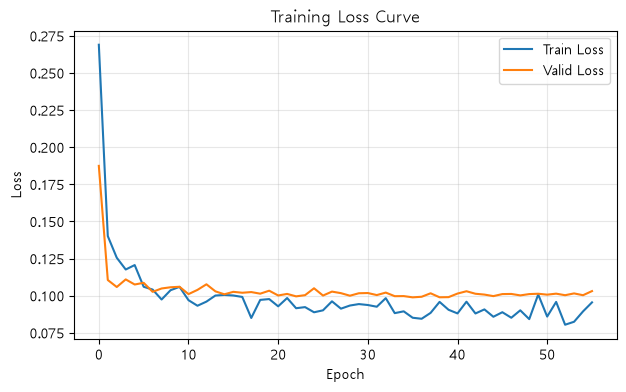

In [53]:
plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['valid_loss'], label='Valid Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

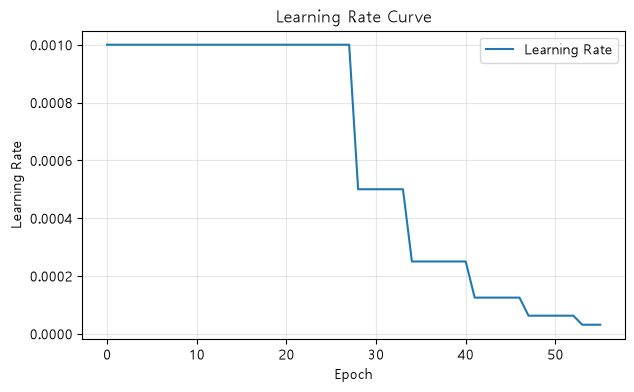

In [54]:
plt.figure(figsize=(7, 4))
plt.plot(history['lr'], label='Learning Rate')
plt.title('Learning Rate Curve')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [56]:
def inverse_target(y_scaled):
    y_log_restored = y_scaled * y_std + y_mean

    return np.expm1(y_log_restored)

def predict_loader(model, data_loader, device):
    model.eval()
    preds = []
    target_list = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)

            output = model(X_batch)

            preds.append(output.cpu().numpy())
            target_list.append(y_batch.numpy())

    preds = np.vstack(preds).ravel()
    y_true = np.vstack(target_list).ravel()

    return preds, y_true

In [57]:
test_pred_scaled, test_true_scaled = predict_loader(model, test_loader, device)

test_pred = inverse_target(test_pred_scaled)
test_true = inverse_target(test_true_scaled)

mae = mean_absolute_error(test_true, test_pred)
rmse = np.sqrt(mean_squared_error(test_true, test_pred))
r2 = r2_score(test_true, test_pred)

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

MAE: 2184.6027
RMSE: 4485.4998
R2: 0.8704


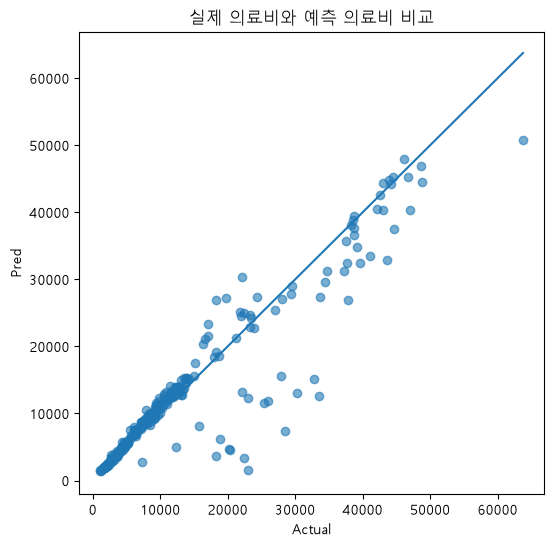

In [59]:
plt.figure(figsize=(6, 6))
plt.scatter(test_true, test_pred, alpha=0.6)
plt.plot(
    [test_true.min(), test_true.max()],
    [test_true.min(), test_true.max()],
)

plt.title('실제 의료비와 예측 의료비 비교')
plt.xlabel('Actual')
plt.ylabel('Pred')
plt.show()

잔차: 실제값-예측값

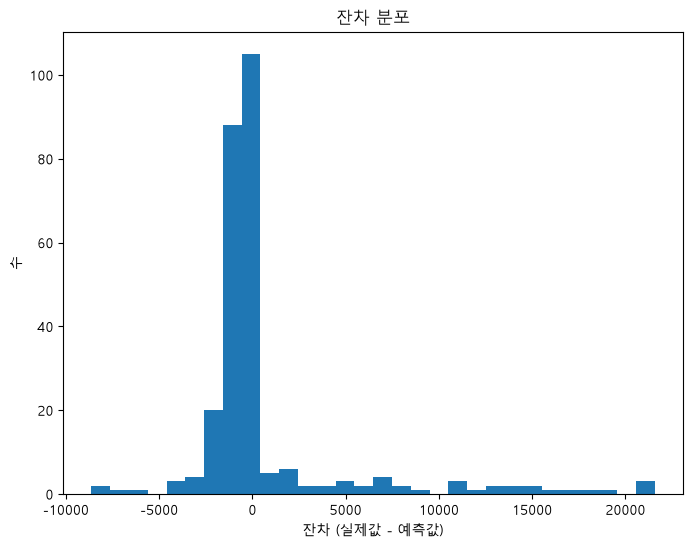

In [61]:
residual = test_true - test_pred

plt.figure(figsize=(8, 6))
plt.hist(residual, bins=30)
plt.title('잔차 분포')
plt.xlabel('잔차 (실제값 - 예측값)')
plt.ylabel('수')
plt.show()

In [62]:
result_df = pd.DataFrame({
    'autual': test_true,
    'predicted': test_pred,
    'residual': residual
})

result_df.head()

,autual,predicted,residual
0,9095.068247,10124.223817,-1029.155570
1,5272.175875,5668.622735,-396.446859
2,29330.981782,27786.216493,1544.765289
3,9301.893542,9357.412381,-55.518839
4,33750.291595,27308.186608,6442.104987


In [65]:
def predict_charge(new_data, model, preprocessor, device):
    new_scaled = preprocessor.transform(new_data)

    new_tensor = torch.FloatTensor(new_scaled).to(device)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(new_tensor).cpu().numpy().ravel()

    pred_charge = inverse_target(pred_scaled)
    return pred_charge

In [66]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [67]:
sample_data = pd.DataFrame([
    {
        'age': 35,
        'sex': 'male',
        'bmi': 27.5,
        'children': 1,
        'smoker': 'no',
        'region': 'southeast'
    },
    {
        'age': 50,
        'sex': 'female',
        'bmi': 32.0,
        'children': 2,
        'smoker': 'yes',
        'region': 'southwest'
    }
])

predict_charge(sample_data, model, preprocessor, device)

array([ 5197.13167089, 35294.75024181])